In [ ]:
import os, sys, time
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns, scanpy as sc

sys.path.append('../../../')
from polygene.model.model import load_trained_model
neural_network_path = "/media/lleger/LaCie/mit/runs/polygene_unit_sphere/"
model, tokenizer = load_trained_model(neural_network_path, checkpoint_n=12)

atlas_path =  "/media/rohola/ssd_storage/lung_cancer_atlas/"
luca_atlas = sc.concat([sc.read_h5ad(atlas_path + file) for file in os.listdir(atlas_path)])
nan_mask = ~(pd.isna(luca_atlas.obs['uicc_stage']) | pd.isna(luca_atlas.obsm['X_scVI'].sum(axis=1)))
luca_atlas = luca_atlas[nan_mask]
subsample = np.random.choice(np.arange(len(luca_atlas)), size=int(2e4), replace=False)
luca_atlas = luca_atlas[subsample].copy()
print(luca_atlas.shape)
#print(luca_atlas.obs.value_counts('disease'), luca_atlas.obs.value_counts('cell_type'))
#embeddings = np.load('lung_cancer_atlas_embeddings.npy')[nan_mask][subsample]
embeddings = np.load('polygene_embeddings.npy')[nan_mask][subsample]
luca_atlas.obsm['polygene'] = embeddings
luca_atlas.obsm['X'] = luca_atlas.X.toarray()
uicc_stages_numerical = luca_atlas.obs['uicc_stage'].apply(lambda x: {'non-cancer': 0, 'I': 1, 'II': 2, 'III': 3, 'IV': 4, 'III or IV': 3.5}[x]).to_numpy()

loading checkpoint-600000
(20000, 17764)


: 

In [8]:
uicc_stages_numerical = luca_atlas.obs['uicc_stage'].apply(lambda x: {'non-cancer': 0, 'I': 1, 'II': 2, 'III': 3, 'IV': 4, 'III or IV': 3.5}[x]).to_numpy()

In [4]:
import torch
import torch.nn as nn
from tqdm import tqdm
import torch.nn.functional as F

timepoints = 50
train_steps= 500

W = model.prediction_head[-1].weight
tau = model.temperature
decoder = lambda z: model.prediction_head(z / z.norm()) / model.temperature

class Geodesic(nn.Module):
    def __init__(self, z_a, z_b, decoder, steps, device="cuda:0", dtype=torch.float32, learning_rate=1e-3, display_tqdm=False, noise_level=0.09):
        super().__init__()
        self.decoder = decoder; self.steps = steps; self.lr = learning_rate; self.display_tqdm = display_tqdm
        z_a = torch.as_tensor(z_a, dtype=dtype, device=device).view(1, -1)
        z_a /= z_a.norm(dim=-1)
        z_b = torch.as_tensor(z_b, dtype=dtype, device=device).view(1, -1)
        z_b /= z_b.norm(dim=-1)
        self.register_buffer("z_a", z_a); self.register_buffer("z_b", z_b)
        t = torch.linspace(0, 1, 10, device=device, dtype=dtype)[1:-1].unsqueeze(1)
        self.interior_positions = nn.Parameter(z_a + t * (z_b - z_a))
        self.interior_positions.data = self.interior_positions.data + noise_level * torch.randn_like(self.interior_positions)
        self.interior_positions.data = self.interior_positions.data / self.interior_positions.data.norm(dim=-1, keepdim=True)
        self.energy_steps = []

    @property
    def positions(self): return torch.cat([self.z_a, self.interior_positions, self.z_b], dim=0)
    @property
    def optimization_steps(self): return len(self.energy_steps) - 1
    
    def energy(self):
        z = self.positions
        logits = self.decoder(z)
        logp = F.log_softmax(logits[:-1], dim=-1)
        logq = F.log_softmax(logits[1:], dim=-1)
        p = logp.exp()
        kl_divergence = (p * (logp - logq)).sum(dim=-1).sum()
        energy = 2*kl_divergence / (1.0 / (z.shape[0] - 1))
        return  energy
    
    def optimize(self, schedule=[]):
        for n_discretization in schedule:
            self.resample_path(n_discretization)
            opt = torch.optim.SGD([self.interior_positions], lr=self.lr, momentum=0.9)
            pbar = tqdm(range(self.steps), disable=not self.display_tqdm)
            for iteration in pbar:
                opt.zero_grad(set_to_none=True)
                loss = self.energy()
                pbar.set_description(f"Energy: {loss.item():.4f}")
                loss.backward(); opt.step()
                self.energy_steps.append(loss.item())
            with torch.no_grad():
                self.interior_positions.data = self.interior_positions.data / self.interior_positions.data.norm(dim=-1, keepdim=True)
        return self.positions.detach().cpu().numpy()

    @torch.no_grad()
    def resample_path(self, n_discretization):
        z = self.positions
        distances = torch.cat([torch.tensor([0.0], device=z.device), torch.cumsum(torch.norm(z[1:] - z[:-1], dim=-1), dim=0)])
        targets = torch.linspace(0, distances[-1], n_discretization, device=z.device)
        indices = torch.searchsorted(distances, targets, right=True).clamp(1, z.shape[0] - 1)
        low, high = indices - 1, indices
        fractions = (targets - distances[low]) / (distances[high] - distances[low] + 1e-12)
        new_points = torch.lerp(z[low], z[high], fractions.unsqueeze(1))
        new_points /= new_points.norm(dim=-1, keepdim=True)
        self.interior_positions = nn.Parameter(new_points[1:-1].clone())

In [ ]:
cell_type_constraints = [["malignant cell", "pulmonary alveolar type 2 cell", "epithelial cell of lung"], ["malignant cell", "epithelial cell of lung"]]
disease_contraints = ['lung adenocarcinoma', 'squamous cell lung carcinoma']
np.random.seed(2)

from sklearn.metrics import pairwise_distances
def manifold_neighborhood(curve, manifold, k=1):
    distances = pairwise_distances(curve, manifold)
    curve_timepoint_assignment = distances.argmin(axis=0)

    mask = []
    for t in range(len(curve)):
        indices_assigned_to_t = np.where(curve_timepoint_assignment == t)[0]
        k_closest_indices_assigned_to_t = distances[t, indices_assigned_to_t][:k]
        mask.append( np.isin(np.arange(len(manifold)), k_closest_indices_assigned_to_t) )
    return np.array(mask)

from scipy.spatial.distance import cdist
def manifold_projection(path, manifold, k=10):
    # function to project a smooth path onto a manifold or set of discrete observations

    # path is a (t, d) array

    # manifold is a (n,d) array
    distances = cdist(manifold, path) #(t, n) array
    closest_point_indices = np.argsort(distances, axis=-1)[:, :closest_k]
    return closest_point_indices

average_uicc = {}

for cell_types, disease in zip(cell_type_constraints, disease_contraints):
    manifold = luca_atlas[luca_atlas.obs['disease'].isin([disease, 'normal']) & luca_atlas.obs['cell_type'].isin(cell_types) & ~pd.isna(luca_atlas.obs['uicc_stage'])]

    start_stage, end_stage = 1, 4
    uicc_stages_numerical = manifold.obs['uicc_stage'].apply(lambda x: {'non-cancer': 0, 'I': 1, 'II': 2,  'III': 3, 'IV': 4, 'III or IV': 3}[x]).to_numpy()
    healthy_cells = manifold[uicc_stages_numerical == start_stage]
    terminal_cells = manifold[uicc_stages_numerical == end_stage]
    
    healthy_centroid = healthy_cells.obsm['X'].mean(axis=0)
    closest_to_healthy_centroid = np.linalg.norm(manifold.obsm['X'] - healthy_centroid, axis=-1).argmin()
    sc.pp.highly_variable_genes(manifold)
    sc.pp.pca(manifold, use_highly_variable=True)
    sc.pp.neighbors(manifold, n_neighbors=15, n_pcs=30)
    sc.tl.diffmap(manifold)
    manifold.uns['iroot'] = closest_to_healthy_centroid
    sc.tl.dpt(manifold)

    closest_k = 100
    number_of_time_points = 50
    timepoints = np.linspace(0, 1, num=number_of_time_points)
    for coordinate_system in ['X', 'X_umap', 'X_scANVI', 'polygene', 'X_scVI']:
        
        x_start = healthy_cells.obsm[coordinate_system].mean(axis=0)
        x_end = terminal_cells.obsm[coordinate_system].mean(axis=0)

        geodesic = x_start + timepoints[:, None] * (x_end - x_start)

        manifold_coordinates = manifold.obsm[coordinate_system]

        manifold_mask = manifold_projection(manifold_coordinates, geodesic, k=closest_k)
        average_uicc_stage = [uicc_stages_numerical[mask].mean() for mask in manifold_mask ]#if mask.sum() > .1 * closest_k]
        average_uicc[disease + "-" + coordinate_system] = average_uicc_stage

    dpt = manifold.obs['dpt_pseudotime'].values
    dpt_normalized = (dpt - dpt.min()) / (dpt.max() - dpt.min())
    timepoint_targets = np.linspace(0, 1, number_of_time_points)
    average_uicc[disease + "-" + 'X_dpt'] = [uicc_stages_numerical[np.argsort(np.abs(dpt_normalized - t))[:closest_k]].mean() for t in timepoint_targets]
    
    z_a = healthy_cells.obsm["polygene"].mean(axis=0)
    z_b = terminal_cells.obsm["polygene"].mean(axis=0)
    compute_geodesic = Geodesic(z_a, z_b, decoder=decoder, steps=train_steps, learning_rate=1e-3, display_tqdm=True)
    
    compute_geodesic.optimize([number_of_time_points])
    curve_coordinates = compute_geodesic.positions.detach().cpu().numpy()
    manifold_mask = manifold_projection(manifold.obsm["polygene"], curve_coordinates, k=closest_k)
    average_uicc_stage = [uicc_stages_numerical[mask].mean() for mask in manifold_mask ]#if mask.sum() > .1 * closest_k]
    average_uicc[disease + "-" + "fisher_rao_geodesic"] = average_uicc_stage

/home/lleger/miniconda3/envs/gene/lib/python3.10/site-packages/scanpy/preprocessing/_highly_variable_genes.py:533: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns['hvg'] = {'flavor': flavor}
Energy: 0.3455: 100%|██████████| 500/500 [00:00<00:00, 1024.89it/s]
/home/lleger/miniconda3/envs/gene/lib/python3.10/site-packages/scanpy/preprocessing/_highly_variable_genes.py:533: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns['hvg'] = {'flavor': flavor}
Energy: 0.3751: 100%|██████████| 500/500 [00:00<00:00, 947.11it/s]


In [6]:
average_uicc['lung adenocarcinoma-fisher_rao_geodesic']

[0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.01,
 0.01,
 0.01,
 0.01,
 0.01,
 0.01,
 0.01,
 0.01,
 0.01,
 0.01,
 0.02,
 0.02,
 0.02,
 0.04,
 0.03,
 0.02,
 0.01,
 0.01,
 0.01,
 0.01,
 0.01,
 0.01,
 0.01,
 0.01,
 0.01,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.01,
 0.02,
 0.02,
 0.02,
 0.02,
 0.02,
 0.03,
 0.02,
 0.02,
 0.02,
 0.01,
 0.02,
 0.02,
 0.08,
 0.08,
 0.08,
 0.13,
 0.26,
 0.4,
 0.62,
 0.71,
 0.83,
 0.91,
 0.97,
 1.17,
 1.315,
 1.535,
 1.615,
 1.805,
 2.035,
 2.195,
 2.395,
 2.635,
 2.755,
 2.825,
 2.94,
 2.94,
 3.09,
 3.08,
 3.11,
 3.15,
 3.25,
 3.33,
 3.37,
 3.37,
 3.41,
 3.42,
 3.39,
 3.42,
 3.43,
 3.58,
 3.66,
 3.7,
 3.7,
 3.67,
 3.7,
 3.67,
 3.61,
 3.61,
 3.64,
 3.61,
 3.61,
 3.64]

In [ ]:
average_uicc[]

In [13]:
start_stage

0

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


squamous cell lung carcinoma-fisher_rao_geodesic 0.33591151633986915
squamous cell lung carcinoma-X_dpt -0.8756484257425741
squamous cell lung carcinoma-X_scVI 0.6076720495049506
squamous cell lung carcinoma-polygene 0.12544685148514867
squamous cell lung carcinoma-X_scANVI -0.9107208415841583
squamous cell lung carcinoma-X_umap -0.2539868118811883
squamous cell lung carcinoma-X 0.48109378217821797
lung adenocarcinoma-fisher_rao_geodesic 0.26651949019607846
lung adenocarcinoma-X_dpt -3.617186871287129
lung adenocarcinoma-X_scVI -0.2319430693069311
lung adenocarcinoma-polygene 0.6898361584158414
lung adenocarcinoma-X_scANVI 0.22970191089108893
lung adenocarcinoma-X_umap 0.6281442772277226
lung adenocarcinoma-X 0.7130834059405939


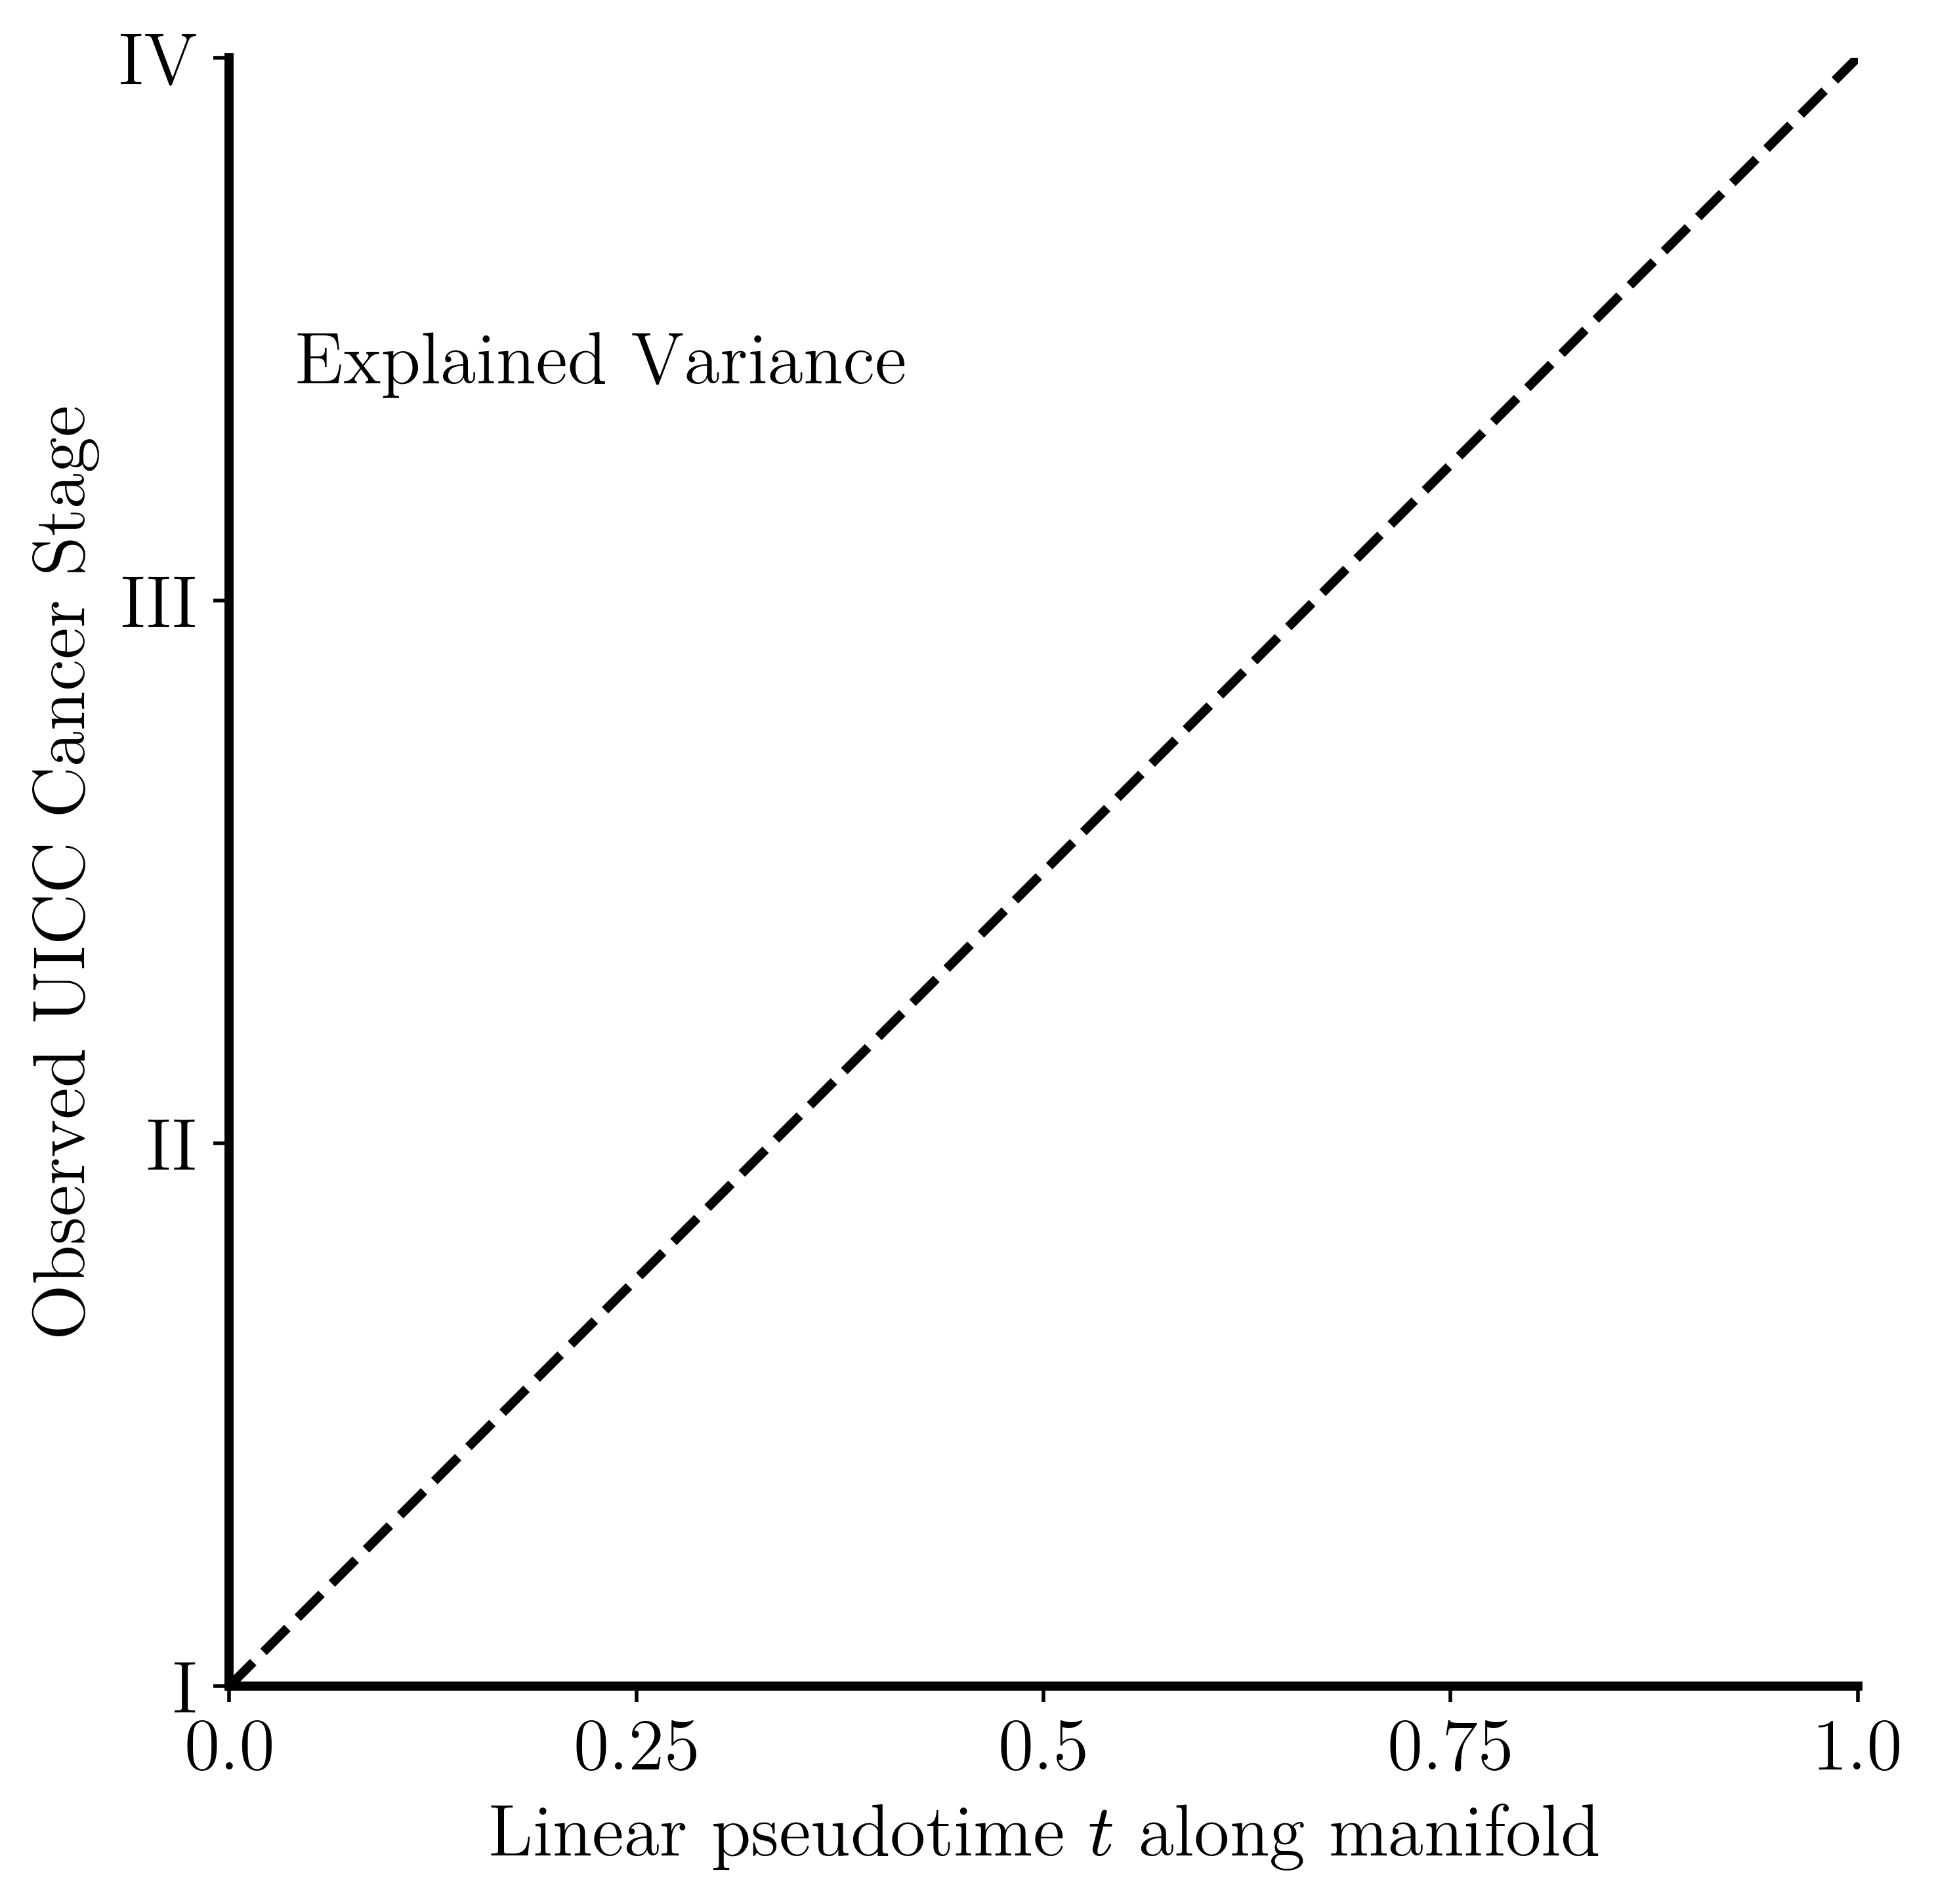

In [15]:
import matplotlib.pyplot as plt, seaborn as sns

from sklearn.metrics import r2_score
plt.rcdefaults()

plt.rcParams['font.family']= 'Latin Modern Roman'
plt.rcParams['mathtext.fontset'] = "cm"

fontsize, dpi = 16, 500
fig, ax = plt.subplots(1, 1, figsize=(6,7), dpi=dpi)
ax.set_aspect('equal')

palette = sns.color_palette('cubehelix_r', n_colors=10)
palette = sns.color_palette('Paired', n_colors=100)
labels = start_stage + (end_stage-start_stage)*timepoints

for idx, coord in enumerate(list(average_uicc.keys())[::-1]):
    #average, pseudo = average_uicc[coord]
    #print(pseudo)
    if not average_uicc[coord]: continue
    labels = start_stage + (end_stage-start_stage)*np.linspace(0, 1, num=len(average_uicc[coord]))
    r2 = r2_score(labels, average_uicc[coord])
    print(coord, r2)
    #print(len(average_uicc[coord]))
    #ax.plot(labels, average_uicc[coord], label=coord.replace('X_umap', 'UMAP').replace(
    #    'X_scANVI', 'scANVI').replace('X', 'Raw Counts').replace('polygene' ,'Polygene') + f': {r2:.2f}',
    #      color=palette[idx],lw=5, alpha=1, zorder=-1)
    
    #ax.scatter(labels, average_uicc[coord], label=coord.replace('X_umap', 'UMAP').replace(
    #    'X_scANVI', 'scANVI').replace('X', 'Raw Counts').replace('polygene' ,'Polygene') + f': {r2:.2f}',
    #      color=palette[idx], s=60,lw=1, edgecolors='k')
    

ax.legend(fontsize=fontsize, frameon=False, title=r"Explained Variance", title_fontsize=fontsize, loc="center left", bbox_to_anchor=(0, 0.8))
ax.set_xticks( np.linspace(1, 4, 5), np.linspace(0, 1, 5), fontsize=fontsize)
#ax.set_xticks([0, 1, 2, 3, 4], ["Healthy", "I", "II", "III", "IV"], fontsize=fontsize)
ax.set_yticks([0, 1, 2, 3, 4], ["", "I", "II", "III", "IV"], fontsize=fontsize)
ax.set_xlabel(r'Linear pseudotime $t$ along manifold', fontsize=fontsize)
ax.set_ylabel('Observed UICC Cancer Stage', fontsize=fontsize)
ax.plot(labels, labels, lw=2, color="k", zorder=-5, alpha=1, ls='--', label=r"$y=x$")
ax.set_xlim(labels.min(), labels.max())
ax.set_ylim(labels.min(), labels.max())
ax.spines[['top', 'right']].set_linewidth(0)
ax.spines[['bottom', 'left']].set_linewidth(2)
#ax.set_title('Disease progression along manifold \n of NSCLC - Lung Adenocarcinoma', fontsize=fontsize*1.2, style='italic')
plt.tight_layout()
#plt.savefig("disease_progression_4.png", dpi=dpi, )#bbox_inches="tight")
plt.show()

In [18]:
manifold.obs['dpt_pseudotime'].values

array([0.13108703 , 0.03373804 , 0.013099352, ..., 0.14795636 ,
       0.14209759 , 0.14339907 ], dtype=float32)

In [ ]:
start_stage, end_stage = 0, 4

healthy_cells = luca_atlas[uicc_stages_numerical == start_stage]

healthy_centroid = healthy_cells.obsm['X'].mean(axis=0)
closest_to_healthy_centroid = np.linalg.norm(luca_atlas.obsm['X'] - healthy_centroid, axis=-1).argmin()

sc.pp.highly_variable_genes(luca_atlas)
sc.pp.pca(luca_atlas, use_highly_variable=True)
sc.pp.neighbors(luca_atlas, n_neighbors=15, n_pcs=30)
sc.tl.diffmap(luca_atlas)
luca_atlas.uns['iroot'] = closest_to_healthy_centroid
sc.tl.dpt(luca_atlas)
luca_atlas.obsm['X_dpt'] = luca_atlas.obs['dpt_pseudotime'].values.reshape(-1, 1)

In [ ]:
from sklearn.metrics import pairwise_distances
def manifold_neighborhood(curve, manifold, k=1):
    distances = pairwise_distances(curve, manifold)
    curve_timepoint_assignment = distances.argmin(axis=0)

    mask = []
    for t in range(len(curve)):
        indices_assigned_to_t = np.where(curve_timepoint_assignment == t)[0]
        k_closest_indices_assigned_to_t = distances[t, indices_assigned_to_t][:k]
        mask.append( np.isin(np.arange(len(manifold)), k_closest_indices_assigned_to_t) )
    return np.array(mask)

closest_k = 100
number_of_time_points = 100
timepoints = np.linspace(0, 1, num=number_of_time_points)
average_uicc = {}
for coordinate_system in ['X', 'X_umap', 'X_scANVI', 'polygene', 'X_scVI']:
    
    x_start = luca_atlas.obsm[coordinate_system].mean(axis=0)
    x_end = luca_atlas.obsm[coordinate_system].mean(axis=0)

    geodesic = x_start + timepoints[:, None] * (x_end - x_start)

    manifold_coordinates = manifold.obsm[coordinate_system]

    manifold_mask = manifold_neighborhood(manifold_coordinates, geodesic, closest_k=closest_k)
    average_uicc_stage = [uicc_stages_numerical[mask].mean() for mask in manifold_mask]
    average_uicc[coordinate_system] = average_uicc_stage

In [ ]:
sc.pp.highly_variable_genes(luca_atlas)
sc.pp.pca(luca_atlas, use_highly_variable=True)
sc.pp.neighbors(luca_atlas, n_neighbors=15, n_pcs=30)
sc.tl.diffmap(luca_atlas)
luca_atlas.uns['iroot'] = closest_to_healthy_centroid
sc.tl.dpt(luca_atlas)
manifold.obsm['X_dpt'] = manifold.obs['dpt_pseudotime'].values.reshape(-1, 1)

cell_type_constraints = [["malignant cell", "pulmonary alveolar type 2 cell"], ["malignant cell", "epithelial cell of lung"]]
disease_contraints = ['lung adenocarcinoma', 'squamous cell lung carcinoma']
np.random.seed(2)
luca_atlas.obsm['polygene'] = embeddings
for cell_types, disease in zip(cell_type_constraints, disease_contraints):
    manifold = luca_atlas[luca_atlas.obs['disease'].isin([disease, 'normal']) & luca_atlas.obs['cell_type'].isin(cell_types) & ~pd.isna(luca_atlas.obs['uicc_stage'])]
    subsample = np.random.choice(np.arange(len(manifold)), size=int(2e4), replace=False)
    manifold = manifold[subsample].copy()
    manifold.obsm['X'] = manifold.X.toarray()

    start_stage, end_stage = 1, 4
    uicc_stages_numerical = manifold.obs['uicc_stage'].apply(lambda x: {'non-cancer': 0, 'I': 1, 'II': 2, 
                                                                        'III': 3, 'IV': 4, 'III or IV': 3.5}[x]).to_numpy()
    healthy_cells = manifold[uicc_stages_numerical == start_stage]
    
    healthy_centroid = healthy_cells.obsm['X'].mean(axis=0)
    closest_to_healthy_centroid = np.linalg.norm(manifold.obsm['X'] - healthy_centroid, axis=-1).argmin()
    sc.pp.highly_variable_genes(manifold)
    sc.pp.pca(manifold, use_highly_variable=True)
    sc.pp.neighbors(manifold, n_neighbors=15, n_pcs=30)
    sc.tl.diffmap(manifold)
    manifold.uns['iroot'] = closest_to_healthy_centroid
    sc.tl.dpt(manifold)
    manifold.obsm['X_dpt'] = manifold.obs['dpt_pseudotime'].values.reshape(-1, 1)

In [ ]:
#gene_expression_euclidean_geodesic 

np.random.seed(4)
luca_atlas.obsm['polygene'] = embeddings
manifold = luca_atlas[luca_atlas.obs['disease'].isin(['squamous cell lung carcinoma', 'normal']) & luca_atlas.obs['cell_type'].isin(['epithelial cell of lung', 'malignant cell'])]
manifold = luca_atlas[luca_atlas.obs['disease'].isin(['lung adenocarcinoma', 'normal'])]
subsample = np.random.choice(np.arange(len(manifold)), size=int(1e4))

manifold = manifold[subsample]
manifold.obsm['X'] = manifold.X.toarray()

start_stage, end_stage = 1, 4
uicc_stages_numerical = manifold.obs['uicc_stage'].apply(lambda x: {'non-cancer': 0, 'I': 1, 'II': 2, 'III': 3, 'IV': 4, 'III or IV': 3.5}[x]).to_numpy()
healthy_centroid = manifold[uicc_stages_numerical == start_stage] 

terminal_centroid = manifold[uicc_stages_numerical == end_stage]

x_start = healthy_centroid.X.toarray().mean(axis=0)
x_end = terminal_centroid.X.toarray().mean(axis=0)

from sklearn.metrics import pairwise_distances
def manifold_neighborhood(curve, manifold, k=1):
    distances = pairwise_distances(curve, manifold)
    curve_timepoint_assignment = distances.argmin(axis=0)

    mask = []
    for t in range(len(curve)):
        indices_assigned_to_t = np.where(curve_timepoint_assignment == t)[0]
        k_closest_indices_assigned_to_t = distances[t, indices_assigned_to_t][:k]
        mask.append( np.isin(np.arange(len(manifold)), k_closest_indices_assigned_to_t) )
    return np.array(mask)


closest_k = 100
number_of_time_points = 100
timepoints = np.linspace(0, 1, num=number_of_time_points)
average_uicc = {}
for coordinate_system in ['X', 'X_umap', 'X_scANVI', 'polygene']:#, 'X_scVI']:

    x_start = healthy_centroid.obsm[coordinate_system].mean(axis=0)
    x_end = terminal_centroid.obsm[coordinate_system].mean(axis=0)

    geodesic = x_start + timepoints[:, None] * (x_end - x_start)

    manifold_coordinates = manifold.obsm[coordinate_system]

    manifold_indices = manifold_projection(manifold_coordinates, geodesic, closest_k=closest_k)
    average_uicc_stage = [uicc_stages_numerical[indices].mean() for indices in manifold_indices]
    average_uicc[coordinate_system] = average_uicc_stage

### Correlate cancer staging from the LuCA dataset to different coordinate system transformations of expression data

In the event it doesn't:
- we can think of trying to improve our current methodology to best answer/reflect in a very short span of time / not likely.
- we can report to what extent it does.
- we can proceed with the other applications of this work.

The evaluation would be how well correlated is the progression from one point to another to the cancer staging labels between two points of non-cancer and and cancer.

1. orignal gene expression vector translation. 
2. PCA
3. PCA + UMAP
2. diffusion pseudotime
3. scVI vector translation
3. scANVI vector translation
4. polyGene vector translation
5. imposing a riemannian geometry yields better structure Polygene + DPT

The metric used to evaluate is the spearman's rank correlation between linear interpolation of cell state coordinates from stage 1 to stage 4 and actual correlations.

In [ ]:
from sklearn.metrics import pairwise_distances
def discretize(curve, manifold, k=1):
    d = pairwise_distances(curve, manifold)
    t_assign = d.argmin(axis=0)
    mask = np.zeros(d.shape, dtype=bool)
    for t in range(curve.shape[0]):
        idx = np.where(t_assign == t)[0]
        if idx.size > k:
            idx = idx[np.argsort(d[t, idx])[:k]]
        mask[t, idx] = True
    return mask

In [49]:
cell_type_constraints = [["malignant cell", "pulmonary alveolar type 2 cell"], ["malignant cell", "epithelial cell of lung"]]
disease_contraints = ['lung adenocarcinoma', 'squamous cell lung carcinoma']
np.random.seed(2)
luca_atlas.obsm['polygene'] = embeddings
for cell_types, disease in zip(cell_type_constraints, disease_contraints):
    manifold = luca_atlas[luca_atlas.obs['disease'].isin([disease, 'normal']) & luca_atlas.obs['cell_type'].isin(cell_types) & ~pd.isna(luca_atlas.obs['uicc_stage'])]
    subsample = np.random.choice(np.arange(len(manifold)), size=int(2e4), replace=False)
    manifold = manifold[subsample].copy()
    manifold.obsm['X'] = manifold.X.toarray()

    start_stage, end_stage = 1, 4
    uicc_stages_numerical = manifold.obs['uicc_stage'].apply(lambda x: {'non-cancer': 0, 'I': 1, 'II': 2, 
                                                                        'III': 3, 'IV': 4, 'III or IV': 3.5}[x]).to_numpy()
    healthy_cells = manifold[uicc_stages_numerical == start_stage]
    
    healthy_centroid = healthy_cells.obsm['X'].mean(axis=0)
    closest_to_healthy_centroid = np.linalg.norm(manifold.obsm['X'] - healthy_centroid, axis=-1).argmin()
    sc.pp.highly_variable_genes(manifold)
    sc.pp.pca(manifold, use_highly_variable=True)
    sc.pp.neighbors(manifold, n_neighbors=15, n_pcs=30)
    sc.tl.diffmap(manifold)
    manifold.uns['iroot'] = closest_to_healthy_centroid
    sc.tl.dpt(manifold)
    manifold.obsm['X_dpt'] = manifold.obs['dpt_pseudotime'].values.reshape(-1, 1)
    
    
    #terminal_cells = manifold[uicc_stages_numerical == end_stage]
    break

#luca_atlas.obs.value_counts('uicc_stage')

In [52]:
np.dot(manifold.obsm['X_dpt'].flatten(), uicc_stages_numerical)/(
    np.linalg.norm(manifold.obsm['X_dpt'].flatten()) * np.linalg.norm( uicc_stages_numerical))

0.5211731464507469

In [53]:
manifold.obsm['X_dist'] = np.linalg.norm(manifold.obsm['X'] - healthy_centroid, axis=-1)

print(np.dot(manifold.obsm['X_dist'].flatten(), uicc_stages_numerical)/(
    np.linalg.norm(manifold.obsm['X_dist'].flatten()) * np.linalg.norm( uicc_stages_numerical)))


0.7327393655729287


In [30]:
healthy_centroid_z.shape

(240,)

In [ ]:
healthy_centroid_z = healthy_cells.obsm['polygene'].mean(axis=0)
manifold.obsm['polygene_dist'] = np.linalg.norm(manifold.obsm['polygene'] - healthy_centroid_z, axis=-1)

print(np.dot(manifold.obsm['polygene_dist'].flatten(), uicc_stages_numerical)/(
    np.linalg.norm(manifold.obsm['polygene_dist']) * np.linalg.norm( uicc_stages_numerical)))

healthy_centroid_z = healthy_cells.obsm['X_scANVI'].mean(axis=0)
manifold.obsm['ANVI_dist'] = np.linalg.norm(manifold.obsm['X_scANVI'] - healthy_centroid_z, axis=-1)

print(np.dot(manifold.obsm['ANVI_dist'], uicc_stages_numerical)/(
    np.linalg.norm(manifold.obsm['ANVI_dist'].flatten()) * np.linalg.norm( uicc_stages_numerical)))

healthy_centroid_z = healthy_cells.obsm['X_scVI'].mean(axis=0)
manifold.obsm['VI_dist'] = np.linalg.norm(manifold.obsm['X_scVI'] - healthy_centroid_z, axis=-1)
namask = ~pd.isna(manifold.obsm['VI_dist'])

print(np.dot(manifold.obsm['VI_dist'][namask], uicc_stages_numerical[namask])/(
    np.linalg.norm(manifold.obsm['VI_dist'][namask]) * np.linalg.norm( uicc_stages_numerical[namask])))

healthy_centroid_z = healthy_cells.obsm['X_scVI'].mean(axis=0)
manifold.obsm['VI_dist'] = np.linalg.norm(manifold.obsm['X_scVI'] - healthy_centroid_z, axis=-1)
namask = ~pd.isna(manifold.obsm['VI_dist'])

print(np.dot(manifold.obsm['VI_dist'][namask], uicc_stages_numerical[namask])/(
    np.linalg.norm(manifold.obsm['VI_dist'][namask]) * np.linalg.norm( uicc_stages_numerical[namask])))

0.7400670738948331
0.7229235506599917


AttributeError: 'ArrayView' object has no attribute 'nanmean'

In [48]:
healthy_centroid_z = healthy_cells.obsm['X_umap'].mean(axis=0)
manifold.obsm['umap_dist'] = np.linalg.norm(manifold.obsm['X_umap'] - healthy_centroid_z, axis=-1)
namask = ~pd.isna(manifold.obsm['umap_dist'])

print(np.dot(manifold.obsm['umap_dist'][namask], uicc_stages_numerical[namask])/(
    np.linalg.norm(manifold.obsm['umap_dist'][namask]) * np.linalg.norm( uicc_stages_numerical[namask])))

0.853638078828742


1008

In [26]:
uicc_stages_numerical

array([4., 4., 1., ..., 0., 0., 4.])

In [ ]:
# representations correlate with progression.
print(list(luca_atlas.obsm.keys()))
luca_atlas.obsm['embeddings']


['X_scANVI', 'X_scVI', 'X_umap']


In [2]:
np.random.seed(4)
luca_atlas.obsm['polygene'] = embeddings
#manifold = luca_atlas[luca_atlas.obs['disease'].isin(['squamous cell lung carcinoma', 'normal']) & luca_atlas.obs['cell_type'].isin(['epithelial cell of lung', 'malignant cell'])]
manifold = luca_atlas[luca_atlas.obs['disease'].isin(['lung adenocarcinoma', 'normal'])]
subsample = np.random.choice(np.arange(len(manifold)), size=int(1e4))

manifold = manifold[subsample]
manifold.obsm['X'] = manifold.X.toarray()

start_stage, end_stage = 0, 4
uicc_stages_numerical = manifold.obs['uicc_stage'].apply(lambda x: {'non-cancer': 0, 'I': 1, 'II': 2, 
                                                                      'III': 3, 'IV': 4, 'III or IV': 3.5}[x]).to_numpy()
healthy_centroid = manifold[uicc_stages_numerical == start_stage] 

terminal_centroid = manifold[uicc_stages_numerical == end_stage]

/tmp/ipykernel_3366032/3062098347.py:8: ImplicitModificationWarning: Setting element `.obsm['X']` of view, initializing view as actual.
  manifold.obsm['X'] = manifold.X.toarray()


In [ ]:
healthy_centroid = manifold[uicc_stages_numerical == start_stage]
healthy_centroid.shape

(3207, 17764)

In [3]:
manifold.obs['cell_type'].value_counts()

malignant cell                    3996
pulmonary alveolar type 2 cell    3956
epithelial cell of lung           2048
Name: cell_type, dtype: int64

In [ ]:
import os, sys, time
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns, scanpy as sc

import os, sys, json
sys.path.append('../../../')
from polygene.model.model import load_trained_model
neural_network_path = "/media/lleger/LaCie/mit/runs/polygene_unit_sphere/"

model, tokenizer = load_trained_model(neural_network_path, checkpoint_n=12)
tokenizer.bypass_inference = True

atlas_path =  "/media/rohola/ssd_storage/lung_cancer_atlas/"
luca_atlas = sc.concat([sc.read_h5ad(atlas_path + file) for file in os.listdir(atlas_path)])

from tqdm import tqdm
from polygene.eval.metrics import prepare_cell

embeddings = np.load('polygene_embeddings.npy')

loading checkpoint-600000


In [ ]:
#gene_expression_euclidean_geodesic 

np.random.seed(4)
luca_atlas.obsm['polygene'] = embeddings
manifold = luca_atlas[luca_atlas.obs['disease'].isin(['squamous cell lung carcinoma', 'normal']) ]#& luca_atlas.obs['cell_type'].isin(['epithelial cell of lung', 'malignant cell'])]
manifold = luca_atlas[luca_atlas.obs['disease'].isin(['lung adenocarcinoma', 'normal'])]
subsample = np.random.choice(np.arange(len(manifold)), size=int(1e4))

manifold = manifold[subsample]
manifold.obsm['X'] = manifold.X.toarray()

start_stage, end_stage = 1, 4
uicc_stages_numerical = manifold.obs['uicc_stage'].apply(lambda x: {'non-cancer': 0, 'I': 1, 'II': 2, 'III': 3, 'IV': 4, 'III or IV': 3.5}[x]).to_numpy()
healthy_cells = manifold[uicc_stages_numerical == start_stage] 
terminal_cells = manifold[uicc_stages_numerical == end_stage]


from scipy.spatial.distance import cdist
from sklearn.metrics import pairwise_distances
def manifold_projection(path, manifold, closest_k=10):
    # function to project a smooth path onto a manifold or set of discrete observations

    # path is a (t, d) array

    # manifold is a (n,d) array
    #distances = cdist(manifold, path) #(t, n) array
    distances = pairwise_distances(manifold, path) #(t, n) array
    closest_point_indices = np.argsort(distances, axis=-1)[:, :closest_k]
    return closest_point_indices

closest_k = 100
number_of_time_points = 100
timepoints = np.linspace(0, 1, num=number_of_time_points)
average_uicc = {}
for coordinate_system in ['X', 'X_umap', 'X_scANVI', 'polygene']:#, 'X_scVI']:

    x_start = healthy_cells.obsm[coordinate_system].mean(axis=0)
    x_end = terminal_cells.obsm[coordinate_system].mean(axis=0)

    geodesic = x_start + timepoints[:, None] * (x_end - x_start)

    manifold_coordinates = manifold.obsm[coordinate_system]

    manifold_indices = manifold_projection(manifold_coordinates, geodesic, closest_k=closest_k)
    average_uicc_stage = [uicc_stages_numerical[indices].mean() for indices in manifold_indices]
    average_uicc[coordinate_system] = average_uicc_stage

/tmp/ipykernel_3414142/203823582.py:10: ImplicitModificationWarning: Setting element `.obsm['X']` of view, initializing view as actual.
  manifold.obsm['X'] = manifold.X.toarray()


NameError: name 'start_stage' is not defined

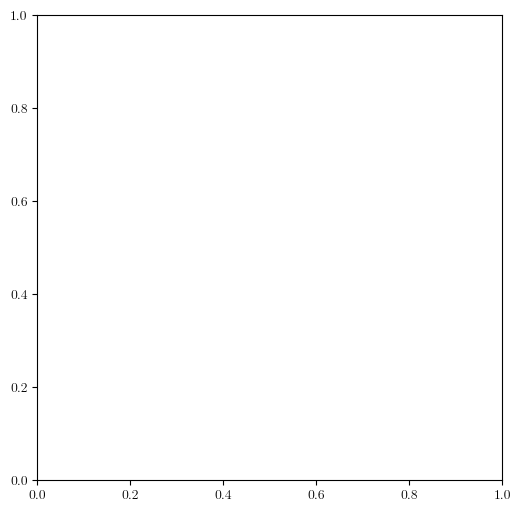

In [1]:
import matplotlib.pyplot as plt, seaborn as sns

from sklearn.metrics import r2_score
plt.rcdefaults()

plt.rcParams['font.family']= 'Latin Modern Roman'
plt.rcParams['mathtext.fontset'] = "cm"

fontsize, dpi = 16, 100
fig, ax = plt.subplots(1, 1, figsize=(6,7), dpi=dpi)
ax.set_aspect('equal')

palette = sns.color_palette('cubehelix_r', n_colors=4)
labels = start_stage + (end_stage-start_stage)*timepoints

for idx, coord in enumerate(list(average_uicc.keys())[::-1]):
    #average, pseudo = average_uicc[coord]
    #print(pseudo)
    print(labels[:3], average_uicc[coord][:3])
    r2 = r2_score(labels, average_uicc[coord])
    #ax.plot(labels, average_uicc[coord], label=coord.replace('X_umap', 'UMAP').replace(
    #    'X_scANVI', 'scANVI').replace('X', 'Raw Counts').replace('polygene' ,'Polygene') + f': {r2:.2f}',
    #      color=palette[idx],lw=5, alpha=1, zorder=-1)
    
    ax.scatter(labels, average_uicc[coord], label=coord.replace('X_umap', 'UMAP').replace(
        'X_scANVI', 'scANVI').replace('X', 'Raw Counts').replace('polygene' ,'Polygene') + f': {r2:.2f}',
          color=palette[idx], s=60,lw=1, edgecolors='k')
    

ax.legend(fontsize=fontsize, frameon=False, title=r"Explained Variance", title_fontsize=fontsize, loc="center left", bbox_to_anchor=(0, 0.8))
ax.set_xticks( np.linspace(1, 4, 5), np.linspace(0, 1, 5), fontsize=fontsize)
#ax.set_xticks([0, 1, 2, 3, 4], ["Healthy", "I", "II", "III", "IV"], fontsize=fontsize)
ax.set_yticks([0, 1, 2, 3, 4], ["", "I", "II", "III", "IV"], fontsize=fontsize)
ax.set_xlabel(r'Linear pseudotime $t$ along manifold', fontsize=fontsize)
ax.set_ylabel('Observed UICC Cancer Stage', fontsize=fontsize)
ax.plot(labels, labels, lw=2, color="k", zorder=-5, alpha=1, ls='--', label=r"$y=x$")
ax.set_xlim(labels.min(), labels.max())
ax.set_ylim(labels.min(), labels.max())
ax.spines[['top', 'right']].set_linewidth(0)
ax.spines[['bottom', 'left']].set_linewidth(2)
ax.set_title('Disease progression along manifold \n of NSCLC - Lung Adenocarcinoma', fontsize=fontsize*1.2, style='normal')
plt.tight_layout()
#plt.savefig("disease_progression_4.png", dpi=dpi, )#bbox_inches="tight")

# Call it something different than Expected UICC stage. Pseudotime. 
plt.show()

In [3]:
import os, sys, time
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns, scanpy as sc

import os, sys, json
sys.path.append('../../../')
from polygene.model.model import load_trained_model
neural_network_path = "/media/lleger/LaCie/mit/runs/polygene_unit_sphere/"

model, tokenizer = load_trained_model(neural_network_path, checkpoint_n=12)
tokenizer.bypass_inference = True

atlas_path =  "/media/rohola/ssd_storage/lung_cancer_atlas/"
luca_atlas = sc.concat([sc.read_h5ad(atlas_path + file) for file in os.listdir(atlas_path)])

from tqdm import tqdm
from polygene.eval.metrics import prepare_cell

embeddings = np.load('polygene_embeddings.npy')

/home/lleger/miniconda3/envs/gene/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


loading checkpoint-600000


In [4]:
#gene_expression_euclidean_geodesic 

np.random.seed(4)
luca_atlas.obsm['polygene'] = embeddings
manifold = luca_atlas[luca_atlas.obs['disease'].isin(['squamous cell lung carcinoma', 'normal']) ]#& luca_atlas.obs['cell_type'].isin(['epithelial cell of lung', 'malignant cell'])]
manifold = luca_atlas[luca_atlas.obs['disease'].isin(['lung adenocarcinoma', 'normal'])]
subsample = np.random.choice(np.arange(len(manifold)), size=int(1e4))

manifold = manifold[subsample]
manifold.obsm['X'] = manifold.X.toarray()

start_stage, end_stage = 1, 4
uicc_stages_numerical = manifold.obs['uicc_stage'].apply(lambda x: {'non-cancer': 0, 'I': 1, 'II': 2, 'III': 3, 'IV': 4, 'III or IV': 3.5}[x]).to_numpy()
healthy_cells = manifold[uicc_stages_numerical == start_stage] 
terminal_cells = manifold[uicc_stages_numerical == end_stage]


from scipy.spatial.distance import cdist
from sklearn.metrics import pairwise_distances
def manifold_projection(path, manifold, closest_k=10):
    # function to project a smooth path onto a manifold or set of discrete observations

    # path is a (t, d) array

    # manifold is a (n,d) array
    #distances = cdist(manifold, path) #(t, n) array
    distances = pairwise_distances(manifold, path) #(t, n) array
    closest_point_indices = np.argsort(distances, axis=-1)[:, :closest_k]
    return closest_point_indices

closest_k = 100
number_of_time_points = 100
timepoints = np.linspace(0, 1, num=number_of_time_points)
average_uicc = {}
for coordinate_system in ['X', 'X_umap', 'X_scANVI', 'polygene']:#, 'X_scVI']:

    x_start = healthy_cells.obsm[coordinate_system].mean(axis=0)
    x_end = terminal_cells.obsm[coordinate_system].mean(axis=0)

    geodesic = x_start + timepoints[:, None] * (x_end - x_start)

    manifold_coordinates = manifold.obsm[coordinate_system]

    manifold_indices = manifold_projection(manifold_coordinates, geodesic, closest_k=closest_k)
    average_uicc_stage = [uicc_stages_numerical[indices].mean() for indices in manifold_indices]
    average_uicc[coordinate_system] = average_uicc_stage

/tmp/ipykernel_3415119/203823582.py:10: ImplicitModificationWarning: Setting element `.obsm['X']` of view, initializing view as actual.
  manifold.obsm['X'] = manifold.X.toarray()


[1.         1.03030303 1.06060606] [1.01, 1.02, 1.08]
[1.         1.03030303 1.06060606] [1.215, 1.215, 1.215]
[1.         1.03030303 1.06060606] [1.19, 1.225, 1.225]
[1.         1.03030303 1.06060606] [1.45, 1.45, 1.47]


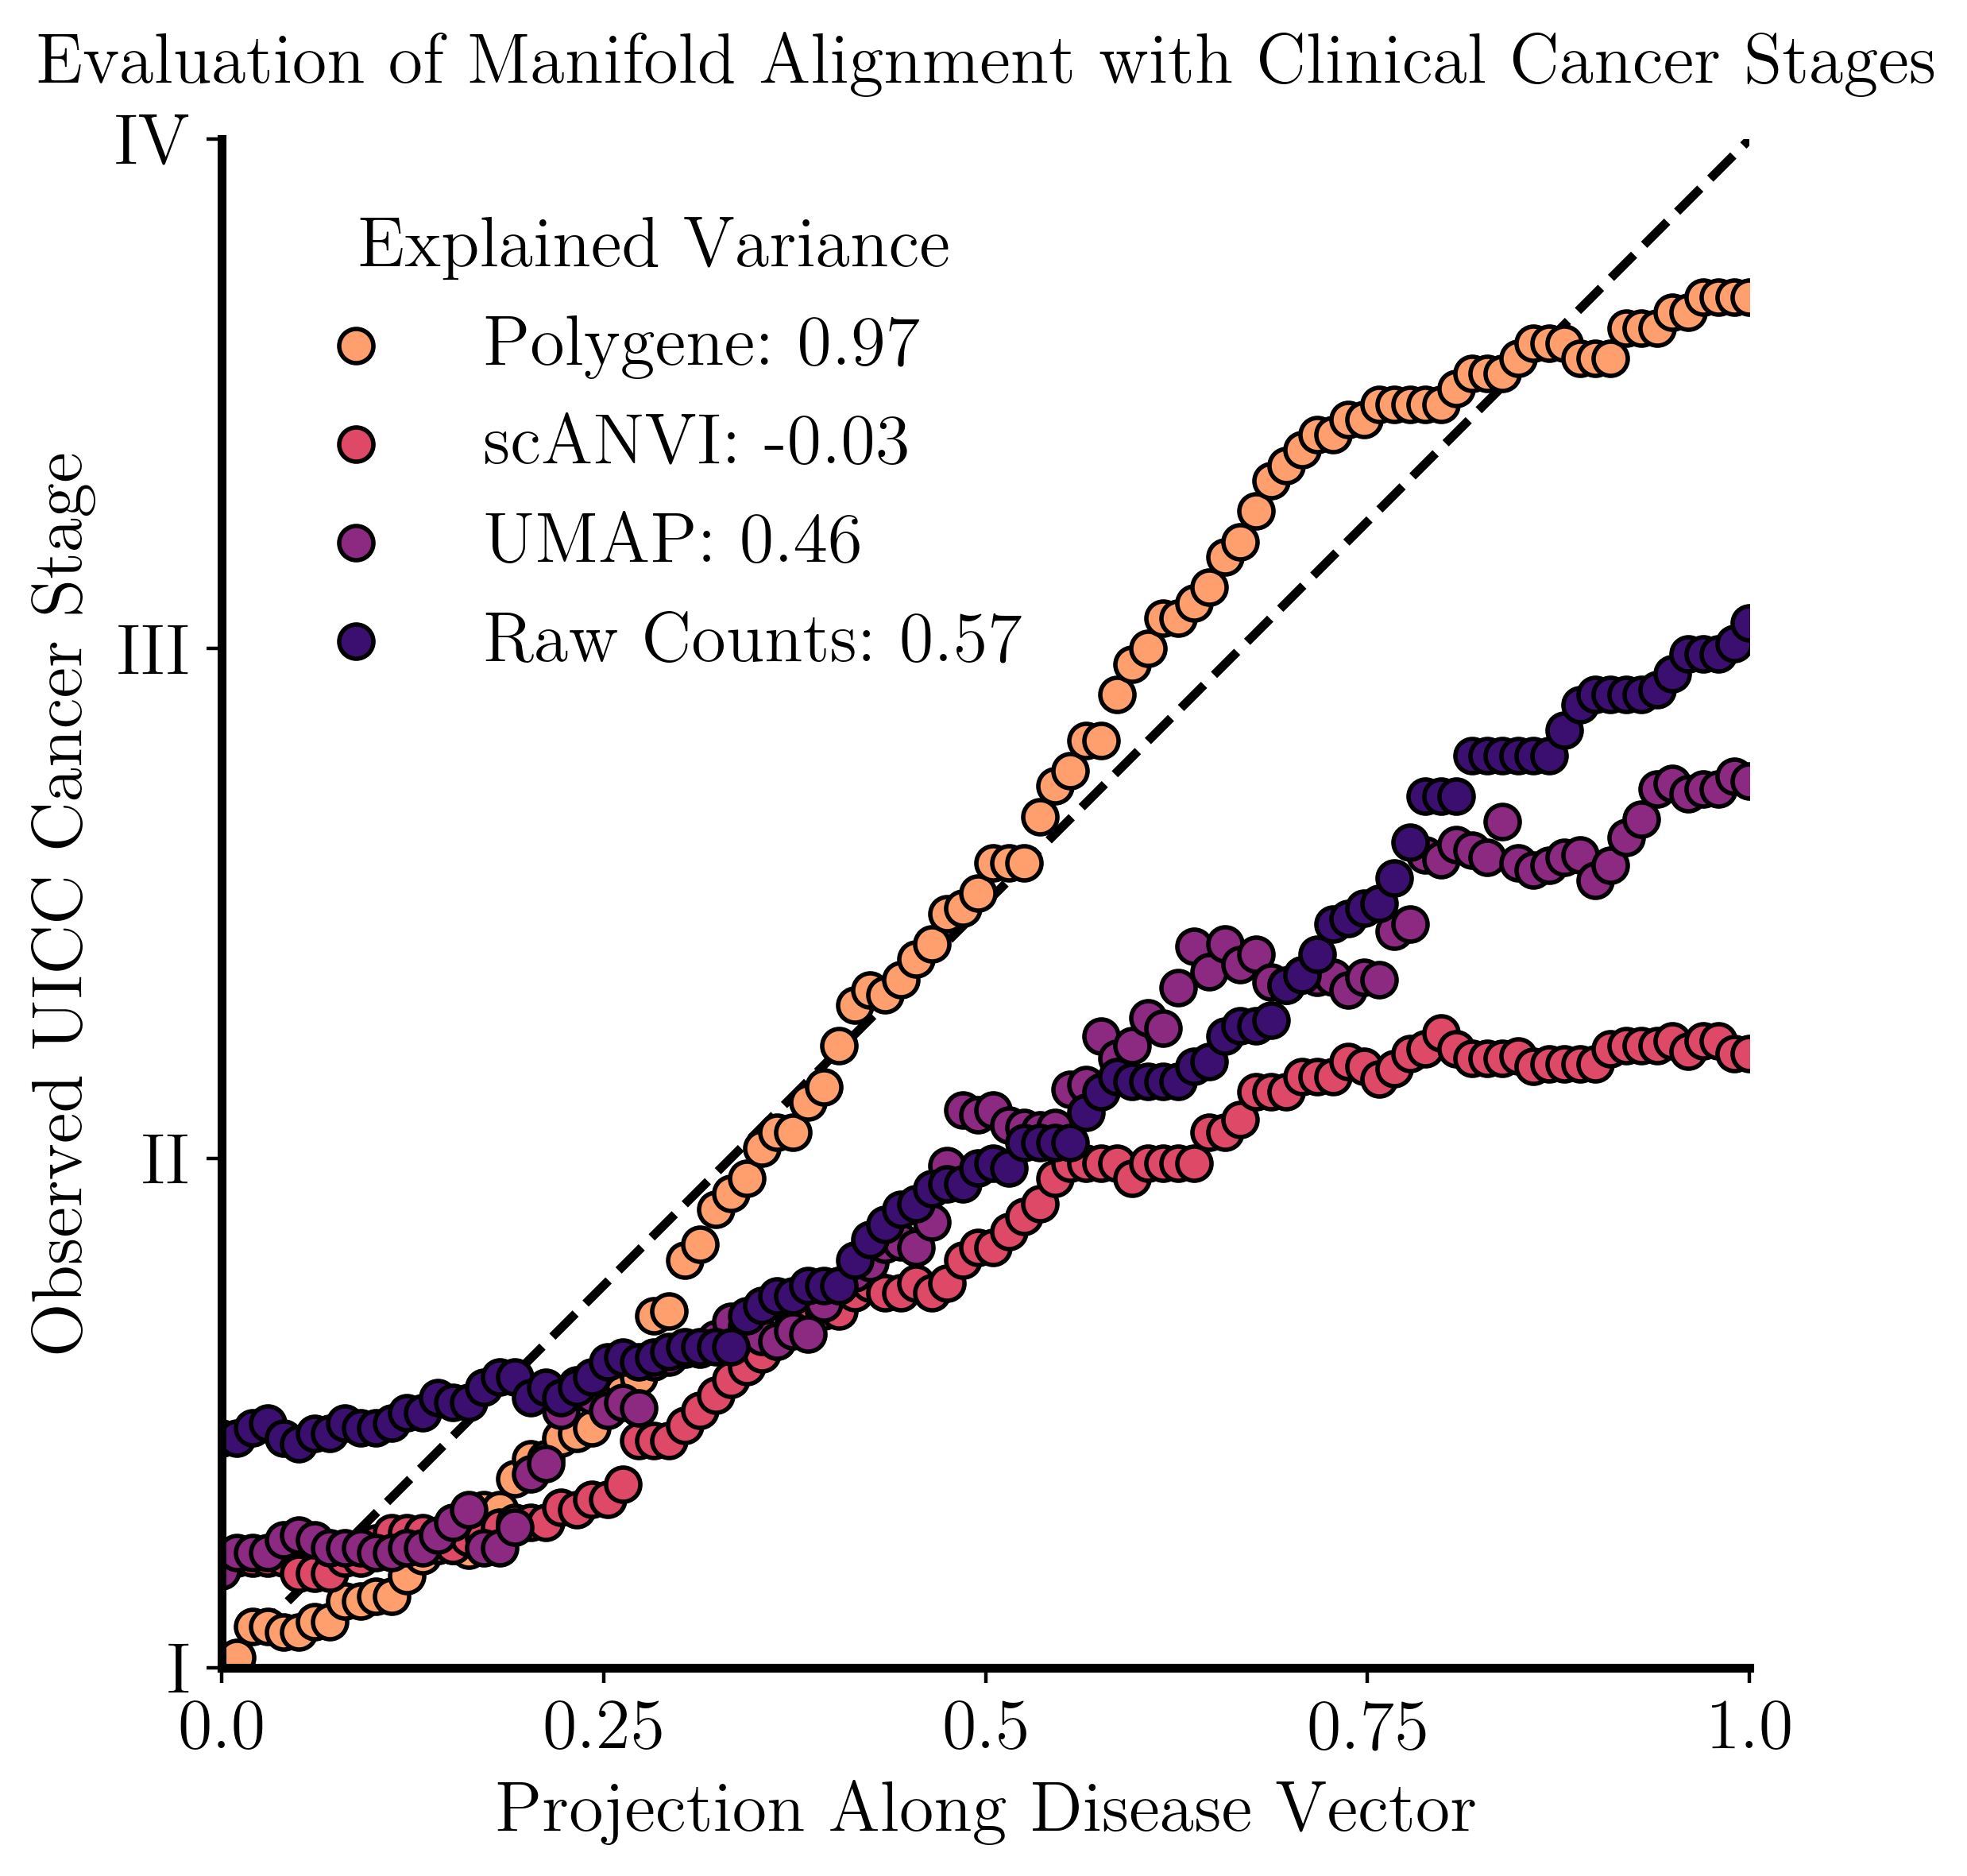

In [31]:
import matplotlib.pyplot as plt, seaborn as sns

from sklearn.metrics import r2_score
plt.rcdefaults()

plt.rcParams['font.family']= 'Latin Modern Roman'
plt.rcParams['mathtext.fontset'] = "cm"

fontsize, dpi = 16, 400
fig, ax = plt.subplots(1, 1, figsize=(6,6), dpi=dpi)
ax.set_aspect('equal')

palette = sns.color_palette('magma_r', n_colors=4)
#palette = sns.color_palette('cubehelix_r', n_colors=4)
labels = start_stage + (end_stage-start_stage)*timepoints

for idx, coord in enumerate(list(average_uicc.keys())[::-1]):
    #average, pseudo = average_uicc[coord]
    #print(pseudo)
    print(labels[:3], average_uicc[coord][:3])
    r2 = r2_score(labels, average_uicc[coord])
    #ax.plot(labels, average_uicc[coord], label=coord.replace('X_umap', 'UMAP').replace(
    #    'X_scANVI', 'scANVI').replace('X', 'Raw Counts').replace('polygene' ,'Polygene') + f': {r2:.2f}',
    #      color=palette[idx],lw=5, alpha=1, zorder=-1)
    
    ax.scatter(labels, average_uicc[coord], label=coord.replace('X_umap', 'UMAP').replace(
        'X_scANVI', 'scANVI').replace('X', 'Raw Counts').replace('polygene' ,'Polygene') + f': {r2:.2f}',
          color=palette[idx], s=60,lw=1, edgecolors='k')
    

ax.legend(fontsize=fontsize, frameon=False, title=r"Explained Variance", title_fontsize=fontsize, loc="center left", bbox_to_anchor=(0, 0.8))
ax.set_xticks( np.linspace(1, 4, 5), np.linspace(0, 1, 5), fontsize=fontsize)
#ax.set_xticks([0, 1, 2, 3, 4], ["Healthy", "I", "II", "III", "IV"], fontsize=fontsize)
ax.set_yticks([0, 1, 2, 3, 4], ["", "I", "II", "III", "IV"], fontsize=fontsize)
ax.set_xlabel(r'Projection Along Disease Vector', fontsize=fontsize)
ax.set_ylabel('Observed UICC Cancer Stage', fontsize=fontsize)
ax.plot(labels, labels, lw=2, color="k", zorder=-5, alpha=1, ls='--', label=r"$y=x$")
ax.set_xlim(labels.min(), labels.max())
ax.set_ylim(labels.min(), labels.max())
ax.spines[['top', 'right']].set_linewidth(0)
ax.spines[['bottom', 'left']].set_linewidth(2)
ax.set_title('Evaluation of Manifold Alignment with Clinical Cancer Stages', fontsize=fontsize, y=1.02)#Disease progression along manifold \n of NSCLC - Lung Adenocarcinoma', fontsize=fontsize*1, style='normal')
plt.tight_layout()
plt.savefig("disease_progression_along_manifold_magma.png", dpi=dpi, bbox_inches="tight")

# Call it something different than Expected UICC stage. Pseudotime. 
plt.show()

In [64]:
np.random.seed(4)
luca_atlas.obsm['polygene'] = embeddings
manifold = luca_atlas[luca_atlas.obs['disease'].isin(['lung adenocarcinoma', 'normal'])]
subsample = np.random.choice(np.arange(len(manifold)), size=int(1e4))
manifold = manifold[subsample]
manifold.obsm['X'] = manifold.X.toarray()

uicc_map = {'non-cancer': 0, 'I': 1, 'II': 2, 'III': 3, 'IV': 4, 'III or IV': 3.5}
uicc_numerical = manifold.obs['uicc_stage'].map(uicc_map).to_numpy()

stages = [1, 2, 3, 4]

from scipy.spatial.distance import cdist

def manifold_projection(manifold_coords, path, closest_k=10):
    return np.argsort(cdist(path, manifold_coords), axis=-1)[:, :closest_k]

closest_k, pts_per_seg = 100, 20
average_uicc = {}

for coord_sys in ['X', 'X_umap', 'X_scANVI', 'polygene']:
    centroids = {s: manifold[uicc_numerical == s].obsm[coord_sys].mean(axis=0) for s in stages}
    segments = []
    for i in range(len(stages) - 1):
        t = np.linspace(0, 1, pts_per_seg)
        segments.append(centroids[stages[i]] + t[:, None] * (centroids[stages[i+1]] - centroids[stages[i]]))
    geodesic = np.vstack(segments)
    indices = manifold_projection(manifold.obsm[coord_sys], geodesic, closest_k)
    average_uicc[coord_sys] = [uicc_numerical[idx].mean() for idx in indices]

/tmp/ipykernel_2923097/1810085164.py:6: ImplicitModificationWarning: Setting element `.obsm['X']` of view, initializing view as actual.
  manifold.obsm['X'] = manifold.X.toarray()


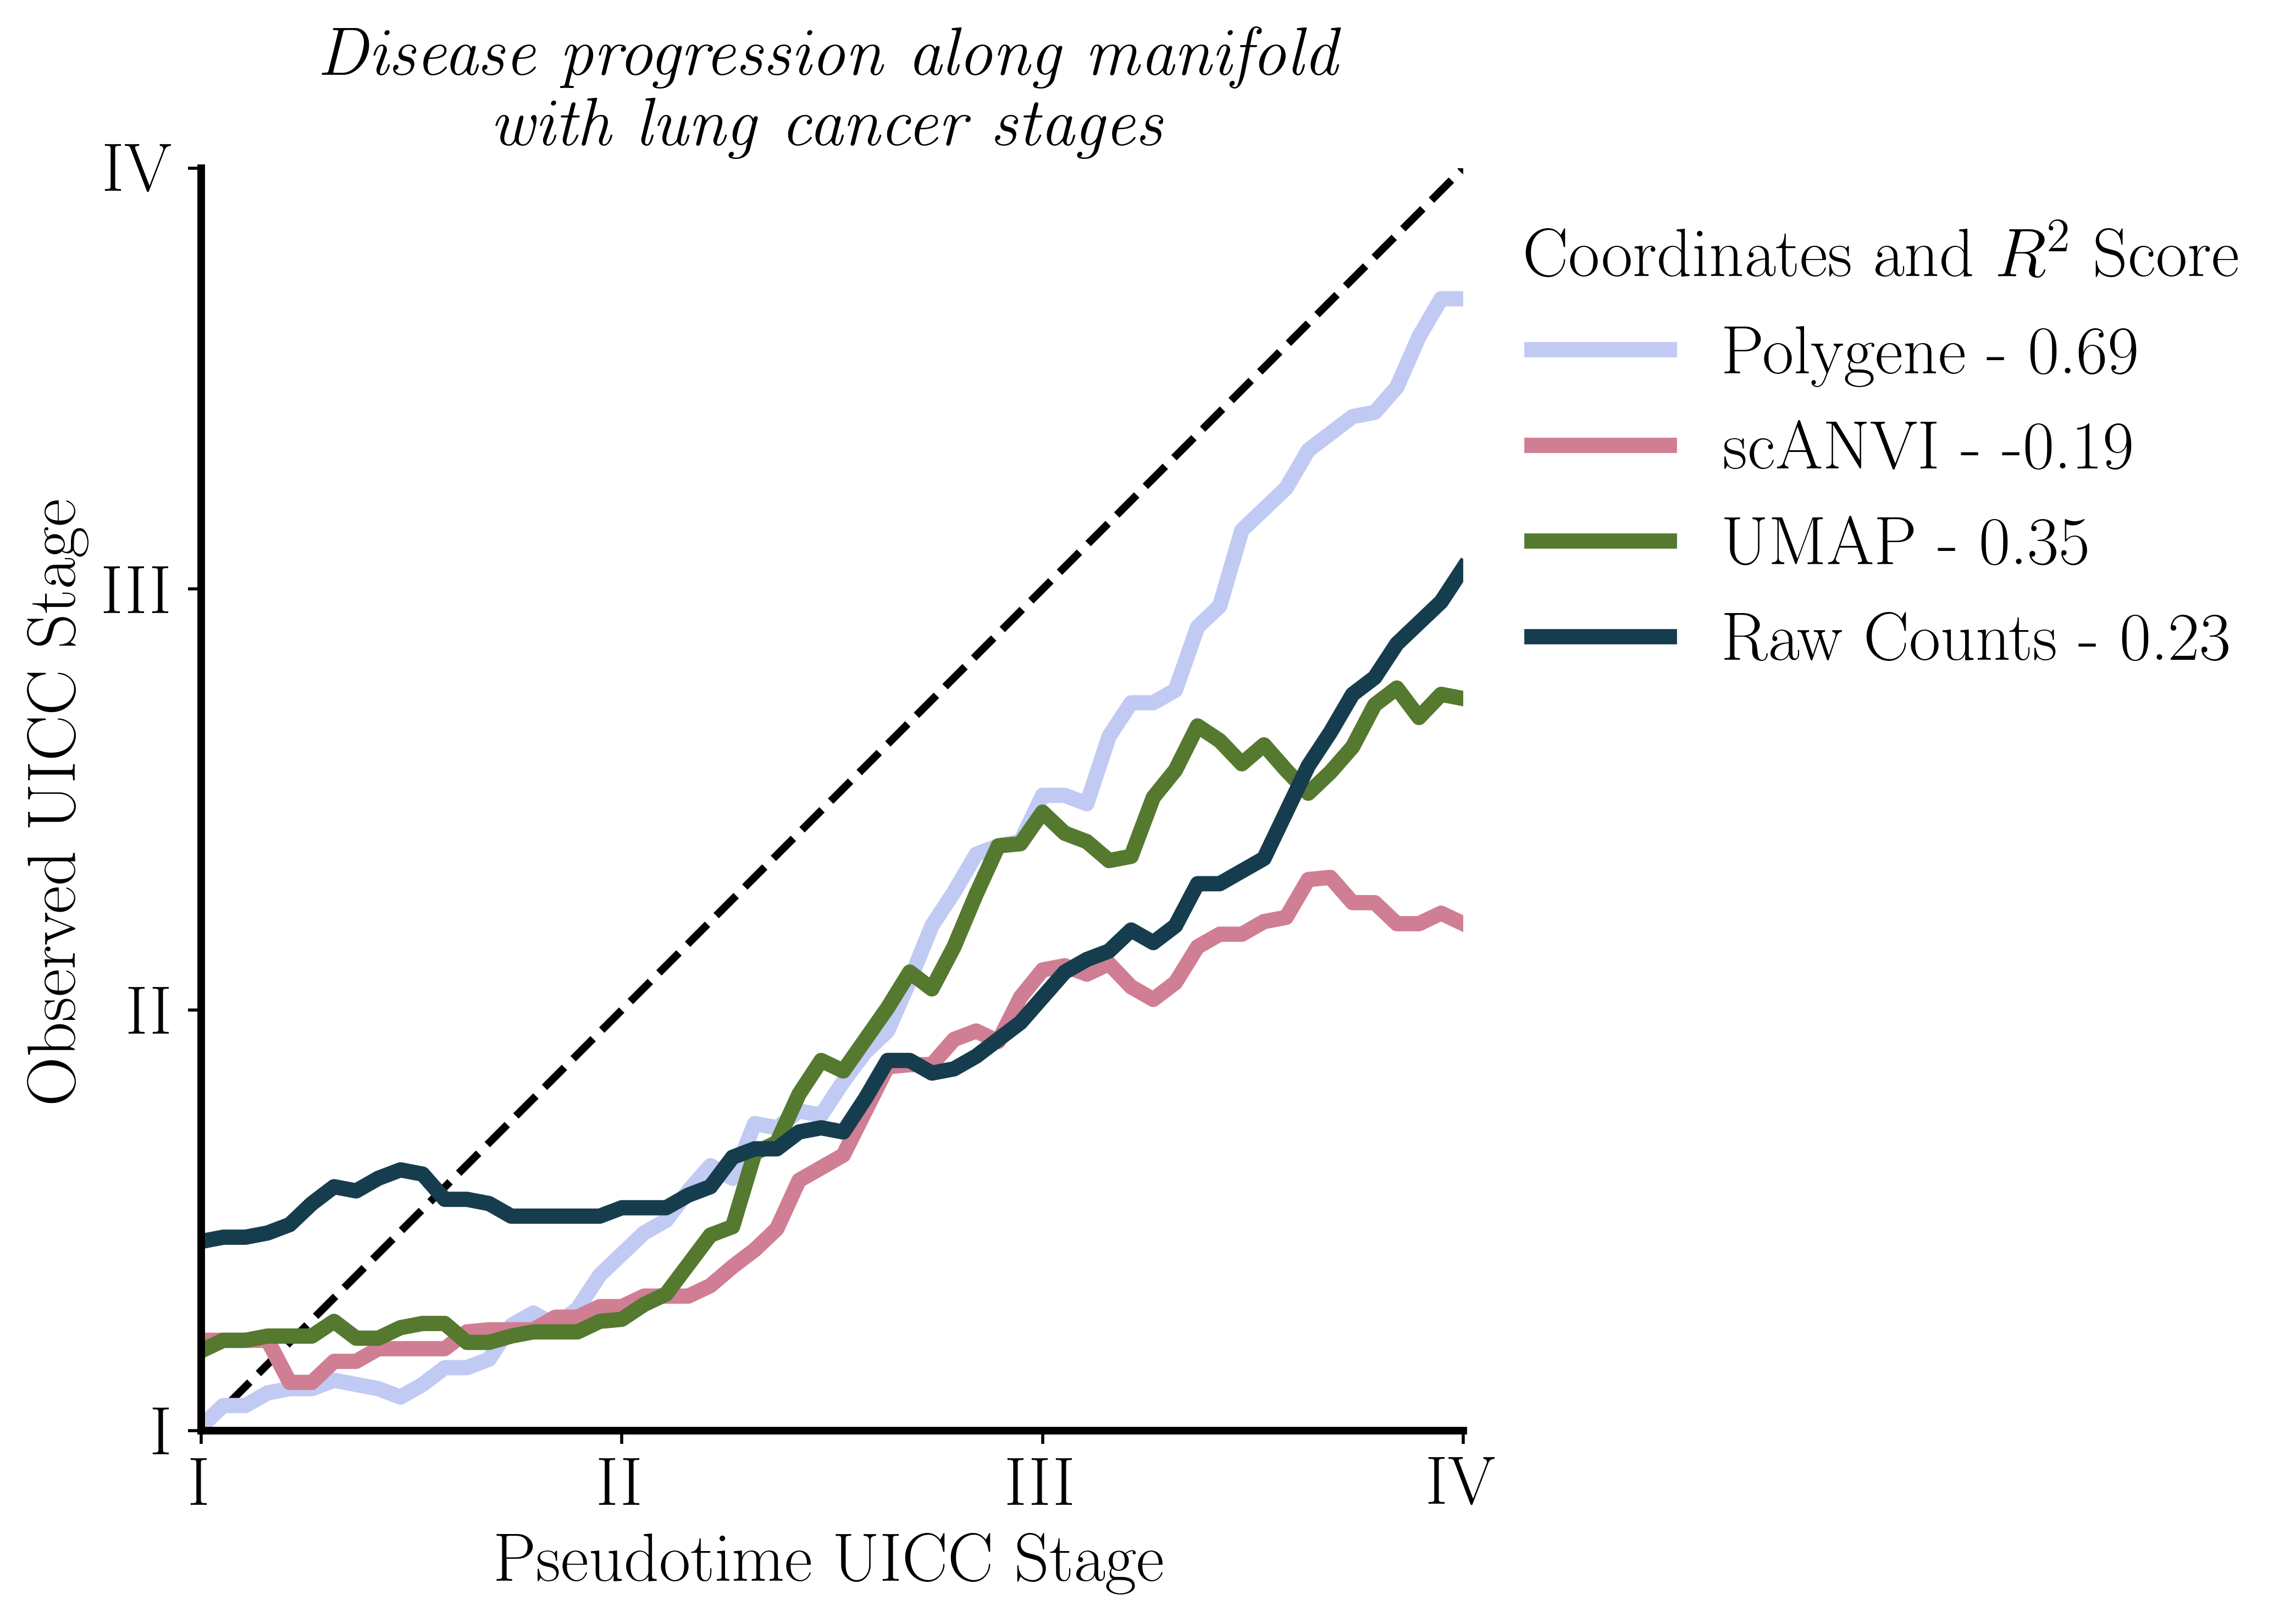

In [65]:
import matplotlib.pyplot as plt, seaborn as sns

from sklearn.metrics import r2_score
plt.rcParams['text.usetex']= True
plt.rcParams['font.family']= 'serif'
plt.rcParams['font.serif'] = ['Latin Modern Roman']

fontsize, dpi = 18, 500
fig, ax = plt.subplots(1, 1, figsize=(8.5,6), dpi=dpi)
ax.set_aspect('equal')

palette = sns.color_palette('cubehelix_r', n_colors=4)
labels = start_stage + (end_stage-start_stage)*timepoints

labels = np.concatenate([np.linspace(stages[i], stages[i+1], pts_per_seg,) for i in range(len(stages) - 1)])

for idx, coord in enumerate(list(average_uicc.keys())[::-1]):
    #average, pseudo = average_uicc[coord]
    #print(pseudo)
    r2 = r2_score(labels, average_uicc[coord])
    ax.plot(labels, average_uicc[coord], label=coord.replace('X_umap', 'UMAP').replace(
        'X_scANVI', 'scANVI').replace('X', 'Raw Counts').replace('polygene' ,'Polygene') + f' - {r2:.2f}',
          color=palette[idx],lw=4,)# edgecolors='k')

ax.legend(fontsize=fontsize, frameon=False, bbox_to_anchor=(1,1), title=r"Coordinates and $R^2$ Score", title_fontsize=fontsize)
ax.set_xticks([0, 1, 2, 3, 4], ["Healthy", "I", "II", "III", "IV"], fontsize=fontsize)
ax.set_yticks([0, 1, 2, 3, 4], ["", "I", "II", "III", "IV"], fontsize=fontsize)
ax.set_xlabel('Pseudotime UICC Stage', fontsize=fontsize)
ax.set_ylabel('Observed UICC Stage', fontsize=fontsize)
ax.plot(labels, labels, lw=2, color="k", zorder=-5, alpha=1, ls='--', label=r"$y=x$")
ax.set_xlim(labels.min(), labels.max())
ax.set_ylim(labels.min(), labels.max())
ax.spines[['top', 'right']].set_linewidth(0)
ax.spines[['bottom', 'left']].set_linewidth(2)
ax.set_title(r'\textit{Disease progression along manifold}' + '\n' + r'\textit{with lung cancer stages}', fontsize=fontsize, )#style='italic')
plt.tight_layout()
#plt.savefig("disease_progression.png", dpi=dpi)

# Call it something different than Expected UICC stage. Pseudotime. 
plt.show()